# M2.Ex2: Automobile Fuel Efficiency

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex2_multi-reg.ipynb)

In [2]:
import pandas as pd
import sklearn
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer    
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler                                                                        
from sklearn.linear_model import LinearRegression    
from sklearn.model_selection import train_test_split



## Auto MPG Dataset

The Auto MPG Dataset is a classic benchmark for regression analysis in machine learning. It originally appeared in the 1983 American Statistical Association (ASA) Exposition and was later donated to the UCI Machine Learning Repository by Ross Quinlan in 1993.

The data consists of technical specifications for various car models from the late 1970s and early 1980s, primarily used to predict fuel efficiency (MPG).

- Features: `5` numerical, `3` categorical
- Target: `mpg` (miles per gallon)
- Size: `398` samples
- Source: [Auto MPG Dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg)

### Step 1. Load the data

In [12]:
df = pd.read_csv("../../../../content/datasets/auto-mpg.csv")

df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce') #it is a string (found out in dtype cell)
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
X = df.drop(columns=['mpg', 'car name'])
y = df['mpg']

### Step 2.b print the type of each

In [4]:
print(f'X: {type(X)}\ndtypes:\n{X.dtypes}')
print('--------------')
print(f'y: {type(y)}\ndtype:\n {y.dtype}')



X: <class 'pandas.DataFrame'>
dtypes:
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model year        int64
origin            int64
dtype: object
--------------
y: <class 'pandas.Series'>
dtype:
 float64


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

Answer:

Target is `Numerical` so we will use Regression

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [5]:
print(X.shape)
print(y.shape)

(398, 7)
(398,)


### Step 4. Summarize the distribution of the data

- Use `describe()` for numerical features
- Use `describe()` for cateogrical features

In [6]:
df.describe(include='all')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000,398
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,305
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ford pinto
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864,NaN
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055,NaN
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,NaN
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000,NaN
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000,NaN
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000,NaN


### Step 5. Plot each of the features vs the target

Hint use this: `sns.pairplot(adv,x_vars=['TV','Radio','Newspaper'],y_vars='Sales',height=6,aspect=0.7,kind='reg')`

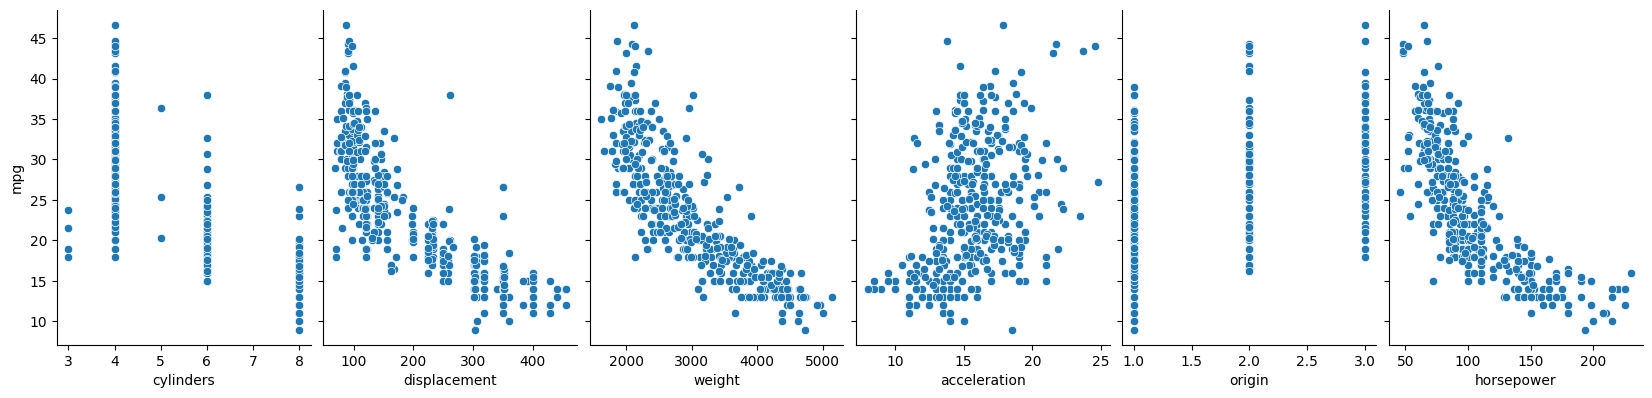

In [11]:
sns.pairplot(df, x_vars=['cylinders', 'displacement', 'weight', 'acceleration', 'origin','horsepower'], y_vars='mpg', height=4, aspect=0.7)


### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=cylinders` and `y=mpg`
2. `x=displacement` and `y=mpg`
3. `x=horsepower` and `y=mpg`
4. `x=weight` and `y=mpg`
5. `x=acceleration` and `y=mpg`

**Answer:**

1. `cylinders` vs `mpg` — **decreasing** (more cylinders → lower mpg)
2. `displacement` vs `mpg` — **decreasing** (larger displacement → lower mpg)
3. `horsepower` vs `mpg` — **decreasing** (more horsepower → lower mpg)
4. `weight` vs `mpg` — **decreasing** (heavier cars → lower mpg)
5. `acceleration` vs `mpg` — **weak increasing** (higher acceleration → slightly higher mpg)

### Step 7. Define the pipeline with pre-processing steps

Raw data is rarely ready for use in ML models. We often need steps such as:

- Handling missing values
- Encoding categorical variables
- Scaling numerical variables

Use `ColumnTransformer` to separate the preprocessing steps of the numerical features from the categorical ones.


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
numerical_cols = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
categorical_cols = ['model year', 'origin'] 

numeric_transformers=Pipeline(steps=[('imputer',SimpleImputer(strategy='mean')),
                                     ('scaler',StandardScaler())])

categorical_tranformer=Pipeline(steps=[('encoder',OneHotEncoder())])

preprocessor = ColumnTransformer(transformers=[('num',numeric_transformers,numerical_cols),
                                                ('cat',categorical_tranformer,categorical_cols)])  

predictor=LinearRegression()




In [7]:
pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", predictor),
    ]
)

### Step 8. Split the dataset into train and test sets

### Step 9.a Fit the pipeline on the training set

In [ ]:
pipe.fit(X_train, y_train)

### Step 9.b Identify the learned coefficients (for each feature) and the bias term

### Step 9.c how much `mpg` we gain if we decrease the weight of the automobile by `100kg`?

### Step 10. Evaluate the pipeline on the test set

In [ ]:
score = pipe.score(X_test, y_test)